# Notebook 01 — Data Preparation
**FracAtlas YOLOv12m Fracture Detection Pipeline**

This notebook converts the raw FracAtlas dataset into a clean YOLO-compatible directory structure,
validates annotations, removes corrupted files, and produces a `data.yaml` config.

> **Run this notebook completely before starting Notebook 02.**


## 0. Install & Import Dependencies

In [1]:
# Install required packages (run once)
# !pip install ultralytics opencv-python-headless pandas tqdm Pillow PyYAML scikit-learn

import os, shutil, csv, json, yaml, random, warnings
import numpy as np
import pandas as pd
from pathlib import Path
from PIL import Image
from tqdm import tqdm
from collections import defaultdict
import matplotlib.pyplot as plt
import matplotlib.patches as patches

warnings.filterwarnings('ignore')
random.seed(42)
np.random.seed(42)
print("Libraries loaded successfully")


Libraries loaded successfully


## 1. Configure Paths

In [ ]:
# ─── EDIT THESE PATHS TO MATCH YOUR SETUP ───────────────────────────────────
BASE_DIR       = Path(".").resolve().parent
IMAGES_DIR     = BASE_DIR / "images"
ANNOT_DIR      = BASE_DIR / "Annotations" / "YOLO"
SPLITS_DIR     = BASE_DIR / "splits"
DATASET_CSV    = BASE_DIR / "dataset.csv"
OUTPUT_DIR     = BASE_DIR / "yolo_dataset"
YAML_PATH      = BASE_DIR / "fracatlas.yaml"
# ─────────────────────────────────────────────────────────────────────────────

# Derived paths
for split in ["train", "val", "test"]:
    (OUTPUT_DIR / "images" / split).mkdir(parents=True, exist_ok=True)
    (OUTPUT_DIR / "labels" / split).mkdir(parents=True, exist_ok=True)

YAML_PATH.parent.mkdir(parents=True, exist_ok=True)

print(f"Base directory   : {BASE_DIR.resolve()}")
print(f"Images directory : {IMAGES_DIR.resolve()}")
print(f"Annotations dir  : {ANNOT_DIR.resolve()}")
print(f"Output dataset   : {OUTPUT_DIR.resolve()}")


Base directory   : D:\Project Medical Object Detection\FracAtlas
Images directory : D:\Project Medical Object Detection\FracAtlas\images
Annotations dir  : D:\Project Medical Object Detection\FracAtlas\Annotations\YOLO
Output dataset   : D:\Project Medical Object Detection\FracAtlas\yolo_dataset


## 2. Validate Raw Dataset Structure

In [3]:
# Count raw images per category
frac_dir    = IMAGES_DIR / "Fractured"
non_frac_dir = IMAGES_DIR / "Non_fractured"

frac_imgs    = list(frac_dir.glob("*.png")) + list(frac_dir.glob("*.jpg")) + list(frac_dir.glob("*.jpeg"))
non_frac_imgs = list(non_frac_dir.glob("*.png")) + list(non_frac_dir.glob("*.jpg")) + list(non_frac_dir.glob("*.jpeg"))

print(f"Fractured images     : {len(frac_imgs)}")
print(f"Non-fractured images : {len(non_frac_imgs)}")
print(f"Total images         : {len(frac_imgs) + len(non_frac_imgs)}")

# Count annotations
annot_files = list(ANNOT_DIR.glob("*.txt"))
print(f"\nAnnotation .txt files: {len(annot_files)}")


Fractured images     : 717
Non-fractured images : 3366
Total images         : 4083

Annotation .txt files: 4084


## 2.1 EDA: Class Balance Analysis
Checking if the dataset is balanced across 'Fractured' and 'Non-fractured' classes.

Fractured: 717 (17.56%)
Non-fractured: 3366 (82.44%)
Ratio (Non-frac / Frac): 4.69:1


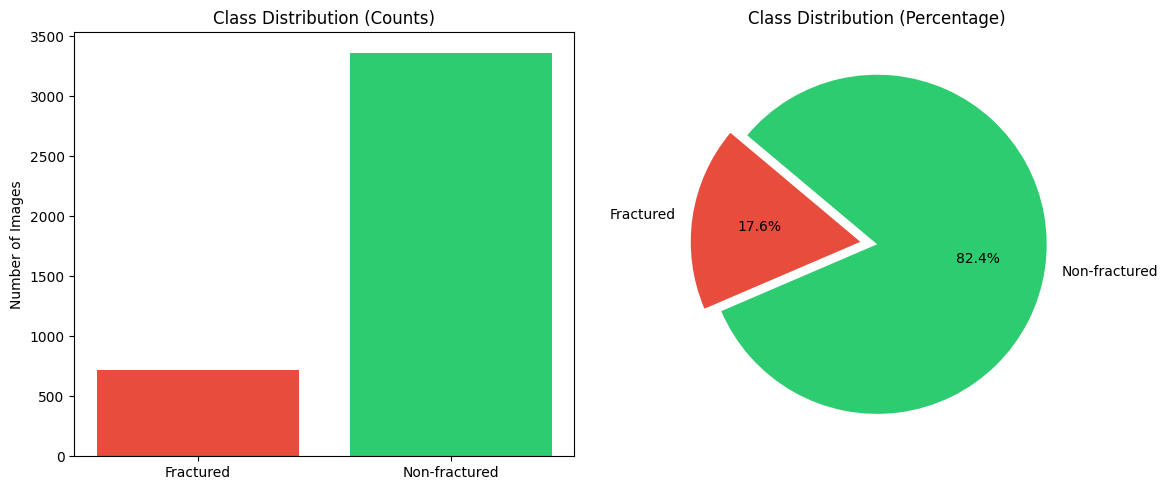

Conclusion: The dataset is IMBALANCED.
There are significantly more Non-fractured images.


In [4]:
# Calculate counts and percentages
n_frac = len(frac_imgs)
n_non_frac = len(non_frac_imgs)
total = n_frac + n_non_frac

perc_frac = (n_frac / total) * 100
perc_non_frac = (n_non_frac / total) * 100

print(f"Fractured: {n_frac} ({perc_frac:.2f}%)")
print(f"Non-fractured: {n_non_frac} ({perc_non_frac:.2f}%)")
print(f"Ratio (Non-frac / Frac): {n_non_frac / n_frac:.2f}:1")

# Visualisation
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

# Bar Chart
ax[0].bar(['Fractured', 'Non-fractured'], [n_frac, n_non_frac], color=['#e74c3c', '#2ecc71'])
ax[0].set_title('Class Distribution (Counts)')
ax[0].set_ylabel('Number of Images')

# Pie Chart
ax[1].pie([n_frac, n_non_frac], labels=['Fractured', 'Non-fractured'], autopct='%1.1f%%', 
        startangle=140, colors=['#e74c3c', '#2ecc71'], explode=(0.1, 0))
ax[1].set_title('Class Distribution (Percentage)')

plt.tight_layout()
plt.show()

# Conclusion
if abs(perc_frac - 50) > 10:
    print("Conclusion: The dataset is IMBALANCED.")
    print(f"There are significantly more {'Non-fractured' if n_non_frac > n_frac else 'Fractured'} images.")
else:
    print("Conclusion: The dataset is relatively BALANCED.")

## 2.2 EDA: Body Part Distribution
Analyzing the distribution of Fractured vs Non-fractured images across different body parts (hand, leg, hip, shoulder, mixed).

In [5]:
# Load dataset metadata
df = pd.read_csv(DATASET_CSV)

# Create image_id to label mapping
img_to_label = {}
for _, row in df.iterrows():
    img_id = row['image_id']
    is_fractured = row['fractured'] == 1
    img_to_label[img_id] = 'Fractured' if is_fractured else 'Non-fractured'

# Body part columns
body_parts = ['hand', 'leg', 'hip', 'shoulder', 'mixed']

# Count fractured and non-fractured per body part
body_part_stats = {}
for part in body_parts:
    part_imgs = df[df[part] == 1]['image_id'].tolist()
    frac_count = sum(1 for img_id in part_imgs if img_to_label.get(img_id) == 'Fractured')
    non_frac_count = sum(1 for img_id in part_imgs if img_to_label.get(img_id) == 'Non-fractured')
    body_part_stats[part] = {'Fractured': frac_count, 'Non-fractured': non_frac_count, 'Total': frac_count + non_frac_count}

# Display statistics
print("Body Part Distribution (Fractured vs Non-fractured):")
print("=" * 60)
for part, stats in body_part_stats.items():
    total = stats['Total']
    if total > 0:
        frac_perc = (stats['Fractured'] / total) * 100
        non_frac_perc = (stats['Non-fractured'] / total) * 100
        print(f"{part.capitalize():12} | Fractured: {stats['Fractured']:4} ({frac_perc:5.1f}%) | Non-fractured: {stats['Non-fractured']:4} ({non_frac_perc:5.1f}%) | Total: {total:4}")
print("=" * 60)


Body Part Distribution (Fractured vs Non-fractured):
Hand         | Fractured:  438 ( 28.5%) | Non-fractured: 1100 ( 71.5%) | Total: 1538
Leg          | Fractured:  263 ( 11.6%) | Non-fractured: 2010 ( 88.4%) | Total: 2273
Hip          | Fractured:   63 ( 18.6%) | Non-fractured:  275 ( 81.4%) | Total:  338
Shoulder     | Fractured:   63 ( 18.1%) | Non-fractured:  286 ( 81.9%) | Total:  349
Mixed        | Fractured:  106 ( 26.6%) | Non-fractured:  292 ( 73.4%) | Total:  398


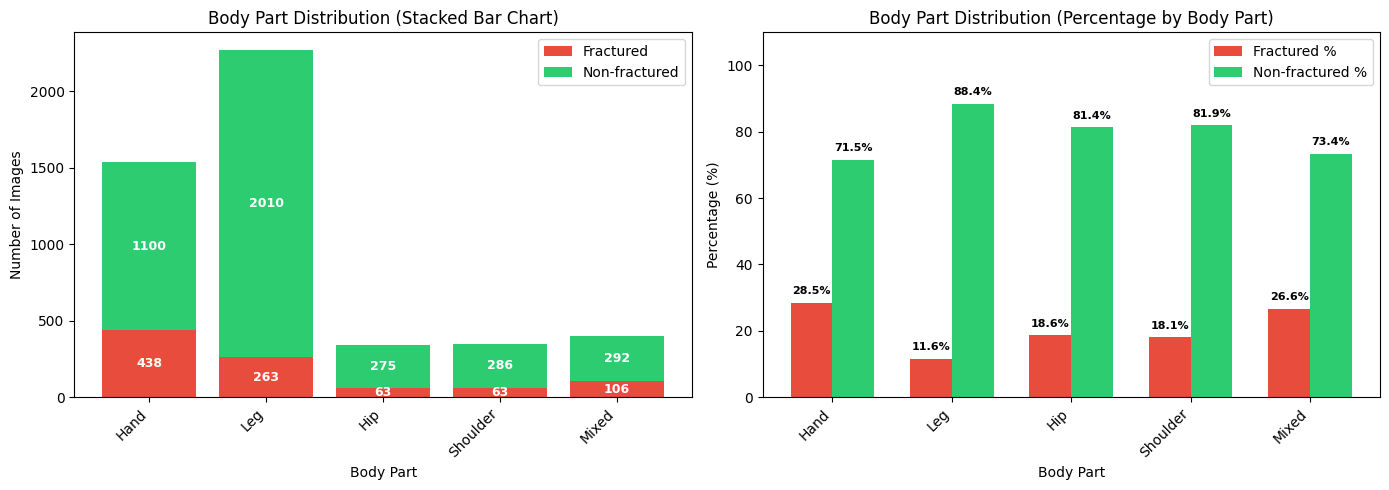


Conclusion:
Overall: 933 Fractured, 3963 Non-fractured (Ratio: 4.25:1)
Most imbalanced body part: Leg (Ratio: 7.64:1)


In [6]:
# Visualization: Stacked Bar Chart
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Stacked bar chart
parts = list(body_part_stats.keys())
frac_counts = [body_part_stats[p]['Fractured'] for p in parts]
non_frac_counts = [body_part_stats[p]['Non-fractured'] for p in parts]

x_pos = np.arange(len(parts))
axes[0].bar(x_pos, frac_counts, label='Fractured', color='#e74c3c')
axes[0].bar(x_pos, non_frac_counts, bottom=frac_counts, label='Non-fractured', color='#2ecc71')
axes[0].set_xlabel('Body Part')
axes[0].set_ylabel('Number of Images')
axes[0].set_title('Body Part Distribution (Stacked Bar Chart)')
axes[0].set_xticks(x_pos)
axes[0].set_xticklabels([p.capitalize() for p in parts], rotation=45, ha='right')
axes[0].legend()

# Add value labels on stacked bars
for i, (fc, nfc) in enumerate(zip(frac_counts, non_frac_counts)):
    axes[0].text(i, fc/2, str(fc), ha='center', va='center', color='white', fontsize=9, fontweight='bold')
    if nfc > 0:
        axes[0].text(i, fc + nfc/2, str(nfc), ha='center', va='center', color='white', fontsize=9, fontweight='bold')

# Grouped bar chart for percentages
frac_percs = [(body_part_stats[p]['Fractured'] / body_part_stats[p]['Total']) * 100 if body_part_stats[p]['Total'] > 0 else 0 for p in parts]
non_frac_percs = [(body_part_stats[p]['Non-fractured'] / body_part_stats[p]['Total']) * 100 if body_part_stats[p]['Total'] > 0 else 0 for p in parts]

width = 0.35
axes[1].bar(x_pos - width/2, frac_percs, width, label='Fractured %', color='#e74c3c')
axes[1].bar(x_pos + width/2, non_frac_percs, width, label='Non-fractured %', color='#2ecc71')
axes[1].set_xlabel('Body Part')
axes[1].set_ylabel('Percentage (%)')
axes[1].set_title('Body Part Distribution (Percentage by Body Part)')
axes[1].set_xticks(x_pos)
axes[1].set_xticklabels([p.capitalize() for p in parts], rotation=45, ha='right')
axes[1].legend()
axes[1].set_ylim(0, 110)

# Add percentage labels
for i, (fp, nfp) in enumerate(zip(frac_percs, non_frac_percs)):
    axes[1].text(i - width/2, fp + 2, f'{fp:.1f}%', ha='center', va='bottom', fontsize=8, fontweight='bold')
    axes[1].text(i + width/2, nfp + 2, f'{nfp:.1f}%', ha='center', va='bottom', fontsize=8, fontweight='bold')

plt.tight_layout()
plt.show()

# Conclusion
print("\nConclusion:")
total_frac = sum(body_part_stats[p]['Fractured'] for p in parts)
total_non_frac = sum(body_part_stats[p]['Non-fractured'] for p in parts)
overall_ratio = total_non_frac / total_frac if total_frac > 0 else float('inf')
print(f"Overall: {total_frac} Fractured, {total_non_frac} Non-fractured (Ratio: {overall_ratio:.2f}:1)")

# Find most imbalanced body part
imbalances = {}
for p in parts:
    if body_part_stats[p]['Fractured'] > 0:
        imbalances[p] = body_part_stats[p]['Non-fractured'] / body_part_stats[p]['Fractured']
if imbalances:
    most_imbalanced = max(imbalances, key=imbalances.get)
    print(f"Most imbalanced body part: {most_imbalanced.capitalize()} (Ratio: {imbalances[most_imbalanced]:.2f}:1)")


## 2.3 Filter Dataset: Hand Images Only
Filtering the dataset to include only hand images for more specific fracture detection (as per supervisor's requirement).

In [7]:
# Load dataset metadata
df = pd.read_csv(DATASET_CSV)

# Filter only hand images
hand_df = df[df['hand'] == 1].copy()

# Get hand image filenames
hand_image_ids = hand_df['image_id'].tolist()

# Filter fractured and non-fractured hand images
hand_frac_imgs = [p for p in frac_imgs if p.name in hand_image_ids]
hand_non_frac_imgs = [p for p in non_frac_imgs if p.name in hand_image_ids]

print("=" * 60)
print("HAND-ONLY DATASET FILTERING")
print("=" * 60)
print(f"\nOriginal dataset:")
print(f"  Total images: {len(frac_imgs) + len(non_frac_imgs)}")
print(f"  Fractured: {len(frac_imgs)}")
print(f"  Non-fractured: {len(non_frac_imgs)}")

print(f"\nFiltered dataset (Hand only):")
print(f"  Total hand images: {len(hand_frac_imgs) + len(hand_non_frac_imgs)}")
print(f"  Hand Fractured: {len(hand_frac_imgs)}")
print(f"  Hand Non-fractured: {len(hand_non_frac_imgs)}")

print(f"\nImages removed:")
print(f"  Total removed: {(len(frac_imgs) + len(non_frac_imgs)) - (len(hand_frac_imgs) + len(hand_non_frac_imgs))}")
print(f"  Fractured removed: {len(frac_imgs) - len(hand_frac_imgs)}")
print(f"  Non-fractured removed: {len(non_frac_imgs) - len(hand_non_frac_imgs)}")
print("=" * 60)

# Update the main image lists to use hand-only images
frac_imgs = hand_frac_imgs
non_frac_imgs = hand_non_frac_imgs
all_images = frac_imgs + non_frac_imgs

print(f"\n✓ Dataset updated to use HAND images only!")
print(f"  New all_images count: {len(all_images)}")


HAND-ONLY DATASET FILTERING

Original dataset:
  Total images: 4083
  Fractured: 717
  Non-fractured: 3366

Filtered dataset (Hand only):
  Total hand images: 1538
  Hand Fractured: 438
  Hand Non-fractured: 1100

Images removed:
  Total removed: 2545
  Fractured removed: 279
  Non-fractured removed: 2266

✓ Dataset updated to use HAND images only!
  New all_images count: 1538


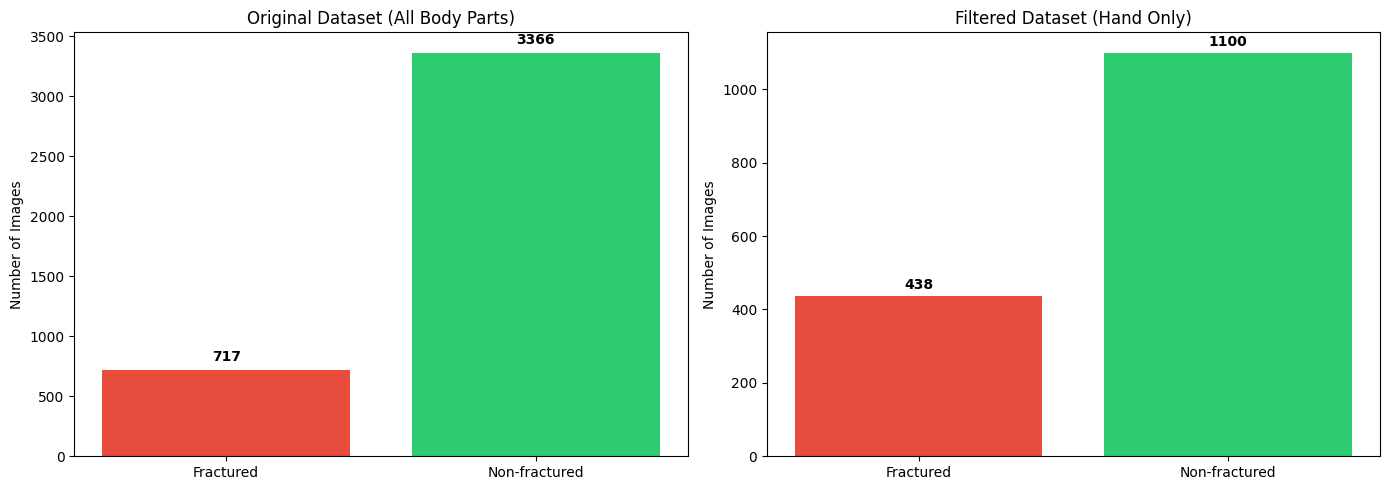


Summary:
  Original: 4083 images
  Hand-only: 1538 images
  Reduction: 62.3%


In [8]:
# Visualization: Before vs After Filtering
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Original dataset
orig_total = len(frac_imgs) + len(hand_non_frac_imgs) + (len(frac_imgs) - len(hand_frac_imgs)) + (len(non_frac_imgs) - len(hand_non_frac_imgs))
orig_frac = len(frac_imgs) + (len(frac_imgs) - len(hand_frac_imgs))
orig_non_frac = len(non_frac_imgs)

# Re-read original counts from CSV for accurate comparison
original_df = pd.read_csv(DATASET_CSV)
orig_frac_count = original_df[original_df['fractured'] == 1].shape[0]
orig_non_frac_count = original_df[original_df['fractured'] == 0].shape[0]

axes[0].bar(['Fractured', 'Non-fractured'], [orig_frac_count, orig_non_frac_count], 
           color=['#e74c3c', '#2ecc71'])
axes[0].set_title('Original Dataset (All Body Parts)')
axes[0].set_ylabel('Number of Images')
for i, v in enumerate([orig_frac_count, orig_non_frac_count]):
    axes[0].text(i, v + 50, str(v), ha='center', va='bottom', fontweight='bold')

# Hand-only dataset
hand_frac_count = len(hand_frac_imgs)
hand_non_frac_count = len(hand_non_frac_imgs)

axes[1].bar(['Fractured', 'Non-fractured'], [hand_frac_count, hand_non_frac_count], 
           color=['#e74c3c', '#2ecc71'])
axes[1].set_title('Filtered Dataset (Hand Only)')
axes[1].set_ylabel('Number of Images')
for i, v in enumerate([hand_frac_count, hand_non_frac_count]):
    axes[1].text(i, v + 10, str(v), ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

print(f"\nSummary:")
print(f"  Original: {orig_frac_count + orig_non_frac_count} images")
print(f"  Hand-only: {hand_frac_count + hand_non_frac_count} images")
print(f"  Reduction: {((orig_frac_count + orig_non_frac_count) - (hand_frac_count + hand_non_frac_count)) / (orig_frac_count + orig_non_frac_count) * 100:.1f}%")


## 2.4 Undersampling (Balancing Classes)
Reducing the number of Non-fractured images to achieve a better ratio for training (Target 2:1 ratio).

In [9]:
# Parameters
TARGET_RATIO = 2.0  # Non-fractured : Fractured
random.seed(42)

n_frac = len(frac_imgs)
n_non_frac_target = int(n_frac * TARGET_RATIO)

if len(non_frac_imgs) > n_non_frac_target:
    print(f"Undersampling Non-fractured from {len(non_frac_imgs)} to {n_non_frac_target}...")
    non_frac_imgs = random.sample(non_frac_imgs, n_non_frac_target)
else:
    print("Non-fractured count is already below target ratio. Skipping undersampling.")

# Re-compile all_images list
all_images = frac_imgs + non_frac_imgs
print(f"New total images: {len(all_images)} ({len(frac_imgs)} Fractured, {len(non_frac_imgs)} Non-fractured)")

Undersampling Non-fractured from 1100 to 876...
New total images: 1314 (438 Fractured, 876 Non-fractured)


## 3. Deep Validation — Corrupted Images & Invalid Annotations

In [10]:
def validate_image(img_path: Path) -> dict:
    """Check if an image can be opened and is not corrupted."""
    result = {"path": img_path, "valid": True, "error": None, "size": None}
    try:
        with Image.open(img_path) as img:
            img.verify()
        with Image.open(img_path) as img:
            result["size"] = img.size
    except Exception as e:
        result["valid"] = False
        result["error"] = str(e)
    return result

def validate_label(label_path: Path, img_w: int = 1, img_h: int = 1) -> dict:
    """Validate YOLO format bounding box label file."""
    result = {"path": label_path, "valid": True, "errors": [], "box_count": 0}
    if not label_path.exists():
        return result   # OK — non-fractured images have no label file
    try:
        lines = label_path.read_text().strip().splitlines()
        result["box_count"] = len(lines)
        for i, line in enumerate(lines):
            parts = line.strip().split()
            if len(parts) != 5:
                result["errors"].append(f"Line {i}: expected 5 values, got {len(parts)}")
                result["valid"] = False
                continue
            cls_id, cx, cy, w, h = parts
            # Class must be 0
            if int(cls_id) != 0:
                result["errors"].append(f"Line {i}: unexpected class id {cls_id}")
            # Coords must be [0, 1]
            for name, val in zip(["cx","cy","w","h"], [cx, cy, w, h]):
                v = float(val)
                if not (0.0 <= v <= 1.0):
                    result["errors"].append(f"Line {i}: {name}={v} out of [0,1]")
                    result["valid"] = False
    except Exception as e:
        result["valid"] = False
        result["errors"].append(str(e))
    return result

# all_images = frac_imgs + non_frac_imgs

print(f"Validating {len(all_images)} images...")
img_results = [validate_image(p) for p in tqdm(all_images)]

corrupt_imgs = [r for r in img_results if not r["valid"]]
print(f"\nValid images  : {len(all_images) - len(corrupt_imgs)}")
print(f"Corrupt images: {len(corrupt_imgs)}")
if corrupt_imgs:
    for r in corrupt_imgs:
        print(f"   {r['path'].name}: {r['error']}")


Validating 1314 images...


100%|██████████| 1314/1314 [00:00<00:00, 2666.91it/s]


Valid images  : 1314
Corrupt images: 0


In [11]:
# Validate all annotation files
print(f"Validating {len(annot_files)} annotation files...")
lbl_results = [validate_label(p) for p in tqdm(annot_files)]

invalid_lbls = [r for r in lbl_results if not r["valid"]]
print(f"\nValid labels  : {len(annot_files) - len(invalid_lbls)}")
print(f"Invalid labels: {len(invalid_lbls)}")
for r in invalid_lbls[:10]:
    print(f"   {r['path'].name}: {r['errors']}")


Validating 4084 annotation files...


100%|██████████| 4084/4084 [00:01<00:00, 3062.51it/s]


Valid labels  : 4084
Invalid labels: 0


## 4. Fix Common Annotation Issues (Auto-Clip)

In [12]:
def fix_label_file(label_path: Path, backup: bool = True) -> int:
    """Clip bounding box values to [0, 1] and remove empty lines.
    Returns number of lines fixed."""
    if not label_path.exists():
        return 0
    lines = label_path.read_text().strip().splitlines()
    fixed_lines, n_fixed = [], 0
    for line in lines:
        parts = line.strip().split()
        if len(parts) != 5:
            continue
        cls_id, cx, cy, w, h = parts
        vals = [float(cx), float(cy), float(w), float(h)]
        clipped = [max(0.0, min(1.0, v)) for v in vals]
        if clipped != vals:
            n_fixed += 1
        # Ensure w/h > 0
        clipped[2] = max(clipped[2], 1e-4)
        clipped[3] = max(clipped[3], 1e-4)
        fixed_lines.append(f"0 {clipped[0]:.6f} {clipped[1]:.6f} {clipped[2]:.6f} {clipped[3]:.6f}")
    if backup and n_fixed > 0:
        label_path.with_suffix(".bak").write_text(label_path.read_text())
    label_path.write_text("\n".join(fixed_lines) + ("\n" if fixed_lines else ""))
    return n_fixed

total_fixed = 0
for lbl in tqdm(annot_files, desc="Fixing labels"):
    total_fixed += fix_label_file(lbl)

print(f"\nTotal bounding boxes auto-clipped: {total_fixed}")
print(" All annotation files cleaned.")


Fixing labels: 100%|██████████| 4084/4084 [00:01<00:00, 2446.60it/s]


Total bounding boxes auto-clipped: 0
 All annotation files cleaned.


## 5. Load Dataset Splits from CSV

In [13]:
def load_split_csv(csv_path: Path) -> list:
    """Read image IDs from a split CSV. Handles multiple column naming conventions."""
    if not csv_path.exists():
        print(f"⚠️  {csv_path} not found — will generate splits automatically.")
        return []
    df = pd.read_csv(csv_path)
    # Try common column names
    for col in ["image_id", "filename", "id", "file", "name"]:
        if col in df.columns:
            return df[col].tolist()
    # Fallback: use first column
    return df.iloc[:, 0].tolist()

train_ids = load_split_csv(SPLITS_DIR / "train.csv")
val_ids   = load_split_csv(SPLITS_DIR / "val.csv")
test_ids  = load_split_csv(SPLITS_DIR / "test.csv")

print(f"Train IDs: {len(train_ids)}")
print(f"Val   IDs: {len(val_ids)}")
print(f"Test  IDs: {len(test_ids)}")


Train IDs: 2857
Val   IDs: 613
Test  IDs: 613


In [14]:
# ── Auto-generate splits if CSVs are missing ──────────────────────────────────
if not train_ids:
    from sklearn.model_selection import train_test_split

    valid_imgs = [r["path"] for r in img_results if r["val"]]
    # Stratify by fractured (has annotation) vs non-fractured
    labels_flag = [1 if (ANNOT_DIR / (p.stem + ".txt")).exists() and
                   (ANNOT_DIR / (p.stem + ".txt")).stat().st_size > 0 else 0
                   for p in valid_imgs]

    train_val, test = train_test_split(valid_imgs, test_size=0.15, stratify=labels_flag, random_state=42)
    labels_tv = [labels_flag[valid_imgs.index(p)] for p in train_val]
    train, val = train_test_split(train_val, test_size=0.1765, stratify=labels_tv, random_state=42)

    train_ids = [p.stem for p in train]
    val_ids   = [p.stem for p in val]
    test_ids  = [p.stem for p in test]

    # Save CSVs for reproducibility
    SPLITS_DIR.mkdir(exist_ok=True)
    pd.DataFrame({"image_id": train_ids}).to_csv(SPLITS_DIR / "train.csv", index=False)
    pd.DataFrame({"image_id": val_ids}).to_csv(SPLITS_DIR / "val.csv", index=False)
    pd.DataFrame({"image_id": test_ids}).to_csv(SPLITS_DIR / "test.csv", index=False)

    print(f" Auto-generated splits → Train: {len(train_ids)} | Val: {len(val_ids)} | Test: {len(test_ids)}")


## 6. Build YOLO Dataset Directory

In [15]:
# Map: image_id -> Path
id_to_path = {p.stem: p for p in all_images}

def copy_split(ids: list, split: str):
    """Copy images and labels into yolo_dataset/<split>/ directories."""
    copied, skipped, missing_img, no_label = 0, 0, 0, 0

    for img_id in tqdm(ids, desc=f"Copying {split}"):
        img_id = str(img_id).replace(".png","").replace(".jpg","").replace(".jpeg","")
        if img_id not in id_to_path:
            missing_img += 1
            continue

        src_img  = id_to_path[img_id]
        src_lbl  = ANNOT_DIR / (img_id + ".txt")
        dst_img  = OUTPUT_DIR / "images" / split / src_img.name
        dst_lbl  = OUTPUT_DIR / "labels" / split / (img_id + ".txt")

        # Copy image
        shutil.copy2(src_img, dst_img)

        # Copy label (or create empty label for non-fractured)
        if src_lbl.exists() and src_lbl.stat().st_size > 0:
            shutil.copy2(src_lbl, dst_lbl)
        else:
            # Non-fractured: create empty label file (YOLO convention)
            dst_lbl.write_text("")
            no_label += 1

        copied += 1

    print(f"  Copied : {copied}")
    print(f"  No label (non-fractured): {no_label}")
    print(f"  Missing image: {missing_img}")

print("=== Copying Train ===")
copy_split(train_ids, "train")
print("\n=== Copying Val ===")
copy_split(val_ids, "val")
print("\n=== Copying Test ===")
copy_split(test_ids, "test")


=== Copying Train ===


Copying train: 100%|██████████| 2857/2857 [00:02<00:00, 1128.26it/s]


  Copied : 922
  No label (non-fractured): 621
  Missing image: 1935

=== Copying Val ===


Copying val: 100%|██████████| 613/613 [00:00<00:00, 1010.65it/s]


  Copied : 194
  No label (non-fractured): 117
  Missing image: 419

=== Copying Test ===


Copying test: 100%|██████████| 613/613 [00:00<00:00, 967.69it/s] 

  Copied : 198
  No label (non-fractured): 138
  Missing image: 415


## 7. Verify Final Dataset Statistics


📊 Dataset Summary:
       images  labels  fractured  non_fractured
train     922     922        301            621
val       194     194         77            117
test      198     198         60            138


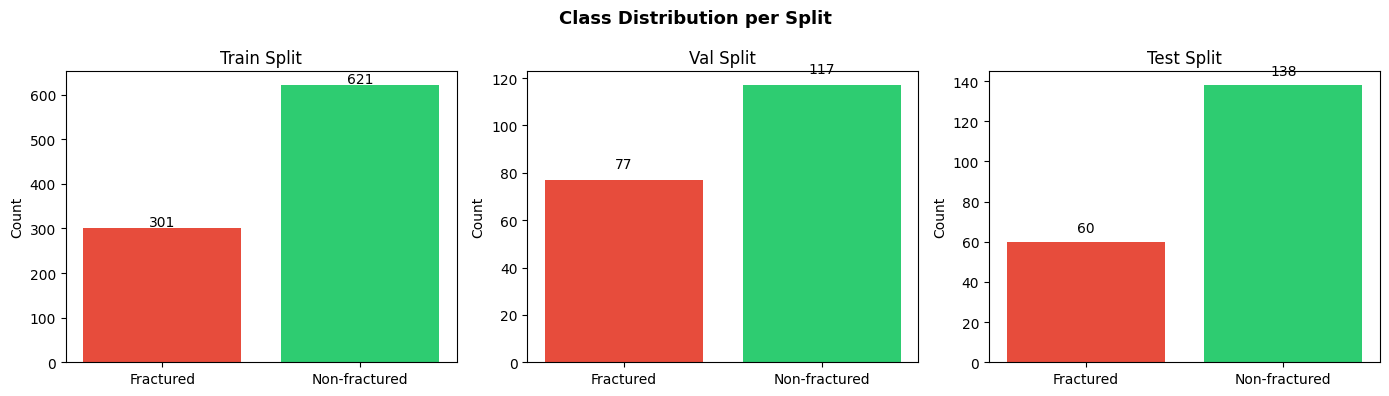

 Saved class_distribution.png


In [16]:
def count_split(split: str) -> dict:
    imgs   = list((OUTPUT_DIR / "images" / split).iterdir())
    labels = list((OUTPUT_DIR / "labels" / split).iterdir())
    n_frac = sum(1 for l in labels if l.stat().st_size > 0)
    return {"images": len(imgs), "labels": len(labels),
            "fractured": n_frac, "non_fractured": len(imgs) - n_frac}

stats = {s: count_split(s) for s in ["train", "val", "test"]}
df_stats = pd.DataFrame(stats).T
print("\n📊 Dataset Summary:")
print(df_stats.to_string())

# Plot class distribution
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, split in zip(axes, ["train", "val", "test"]):
    d = stats[split]
    ax.bar(["Fractured", "Non-fractured"], [d["fractured"], d["non_fractured"]],
           color=["#e74c3c", "#2ecc71"])
    ax.set_title(f"{split.capitalize()} Split")
    ax.set_ylabel("Count")
    for bar in ax.patches:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
                str(int(bar.get_height())), ha='center', fontsize=10)

plt.suptitle("Class Distribution per Split", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(BASE_DIR / "class_distribution.png", dpi=150)
plt.show()
print(" Saved class_distribution.png")


## 8. Visualise Sample Annotations

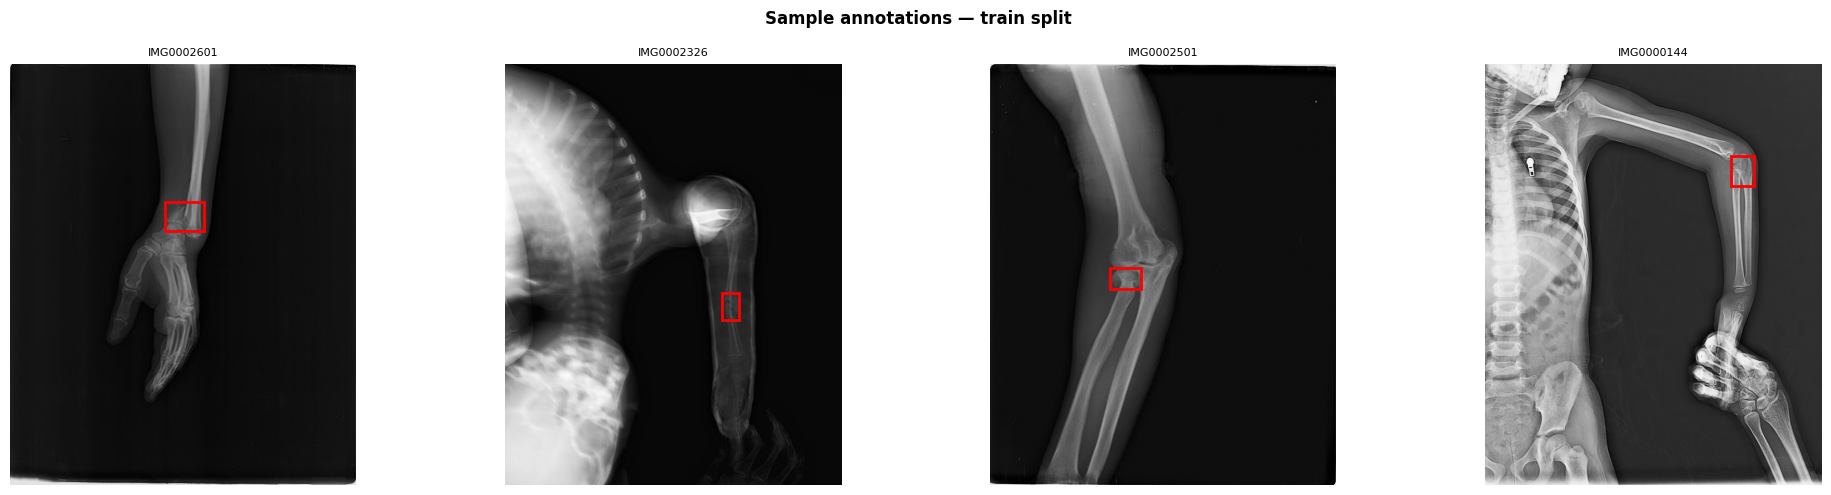

In [17]:
def visualise_samples(split: str = "train", n: int = 4):
    img_dir = OUTPUT_DIR / "images" / split
    lbl_dir = OUTPUT_DIR / "labels" / split
    # Prefer images WITH annotations
    candidates = [p for p in img_dir.iterdir() if (lbl_dir / (p.stem + ".txt")).exists()
                  and (lbl_dir / (p.stem + ".txt")).stat().st_size > 0]
    if not candidates:
        candidates = list(img_dir.iterdir())
    sample = random.sample(candidates, min(n, len(candidates)))

    fig, axes = plt.subplots(1, len(sample), figsize=(5 * len(sample), 5))
    if len(sample) == 1: axes = [axes]
    for ax, img_path in zip(axes, sample):
        img = Image.open(img_path).convert("RGB")
        W, H = img.size
        ax.imshow(img, cmap="gray")
        lbl_path = lbl_dir / (img_path.stem + ".txt")
        if lbl_path.exists():
            for line in lbl_path.read_text().strip().splitlines():
                if not line.strip(): continue
                _, cx, cy, w, h = map(float, line.split())
                x1 = (cx - w/2) * W; y1 = (cy - h/2) * H
                rect = patches.Rectangle((x1, y1), w*W, h*H,
                                         linewidth=2, edgecolor='red', facecolor='none')
                ax.add_patch(rect)
        ax.set_title(img_path.stem[:30], fontsize=8)
        ax.axis('off')
    plt.suptitle(f"Sample annotations — {split} split", fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.savefig(BASE_DIR / f"sample_annotations_{split}.png", dpi=150)
    plt.show()

visualise_samples("train", n=4)


## 9. Generate `data.yaml`

In [18]:
yaml_content = {
    "path"  : str(OUTPUT_DIR.resolve()),
    "train" : "images/train",
    "val"   : "images/val",
    "test"  : "images/test",
    "nc"    : 1,
    "names" : ["fracture"]
}

with open(YAML_PATH, "w") as f:
    yaml.dump(yaml_content, f, default_flow_style=False, sort_keys=False)

print(" data.yaml saved to:", YAML_PATH.resolve())
print("\nContent:")
print(YAML_PATH.read_text())


 data.yaml saved to: D:\Project Medical Object Detection\FracAtlas\datasets\fracatlas.yaml

Content:
path: D:\Project Medical Object Detection\FracAtlas\yolo_dataset
train: images/train
val: images/val
test: images/test
nc: 1
names:
- fracture



## 10. Final Sanity Check

In [19]:
print("=" * 55)
print("FINAL PRE-TRAINING CHECKLIST")
print("=" * 55)

checks = []

# 1. YAML exists
checks.append(("data.yaml exists", YAML_PATH.exists()))

# 2. Images in each split
for split in ["train", "val", "test"]:
    n = len(list((OUTPUT_DIR / "images" / split).iterdir()))
    checks.append((f"{split} images present ({n})", n > 0))

# 3. Labels in each split
for split in ["train", "val", "test"]:
    n = len(list((OUTPUT_DIR / "labels" / split).iterdir()))
    checks.append((f"{split} labels present ({n})", n > 0))

# 4. Fractured samples exist in train
n_frac_train = sum(1 for l in (OUTPUT_DIR / "labels" / "train").iterdir()
                   if l.stat().st_size > 0)
checks.append((f"Fractured train samples ({n_frac_train})", n_frac_train > 0))

all_pass = all(v for _, v in checks)
for msg, ok in checks:
    print(f"  {'' if ok else 'x'} {msg}")

print("=" * 55)
print(f"\n{'Ready for Training! Proceed to Notebook 02.' if all_pass else 'Fix issues above before training.'}")


FINAL PRE-TRAINING CHECKLIST
   data.yaml exists
   train images present (922)
   val images present (194)
   test images present (198)
   train labels present (922)
   val labels present (194)
   test labels present (198)
   Fractured train samples (301)

Ready for Training! Proceed to Notebook 02.
